# 7.2 – Gradient Boosting
This notebook focuses on Gradient Boosting its mathematical explanation, key hyperparameters, and application to a real-world dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, classification_report

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/mushrooms.csv')

The dataset used in this notebook is about mushrooms. All columns are categorical, and the target variable is class, which indicates whether a mushroom is edible or poisonous. This dataset was thoroughly described in my previous notebook on AdaBoosting, so I will not explain all the features again here. If you’re interested in a detailed overview, please refer to the earlier notebook.

In [3]:
data

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

# 1. Gradient Boosting Explanation

**Gradient Boosting** – is an ensemble learning technique that sequentially trains models, where each new model tries to correct the errors made by the previous one. However, instead of reweighting samples like in AdaBoost, Gradient Boosting fits the new model to the negative gradient (residuals) of the loss function with respect to the current ensemble’s predictions. This means each learner is trained to minimize a specified loss function, using a method inspired by gradient descent in function space.

Let the training dataset be:

$$ X = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}, \quad y_i \in \{-1, +1\} $$

The goal is to learn a function $F(x)$ that minimizes the loss function $L(y, F(x))$:

$$
F^*(x) = \arg\min_F \sum_{i=1}^n L(y_i, F(x_i))
$$

1. Initialize the model with a constant value:

$$
F_0(x) = \arg\min_\gamma \sum_{i=1}^n L(y_i, \gamma)
$$

2. For $m = 1$ to $M$ (number of boosting iterations):
     Compute the pseudo-residuals, i.e., the negative gradient of the loss function:

   $$ r_i^{(m)} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]{F(x) = F{m-1}(x)}  $$

     Fit a base learner $h_m(x)$ (typically a decision tree) to the pseudo-residuals:
    
   $$ h_m(x) \approx r_i^{(m)}$$
	
     Compute the optimal step size (also called line search):
   $$ \gamma_m = \arg\min_\gamma \sum_{i=1}^n L\left(y_i, F_{m-1}(x_i) + \gamma \cdot h_m(x_i)\right) $$
	
     Update the model:
   $$ F_m(x) = F_{m-1}(x) + \gamma_m \cdot h_m(x)  $$

3. After $M$ iterations, the final prediction function is:

 $$ F_M(x) = F_0(x) + \sum_{m=1}^M \gamma_m \cdot h_m(x)  $$


In [5]:
X = data.drop('class', axis = 1)

In [6]:
X = pd.get_dummies(X, drop_first = True)

In [7]:
y = data['class']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 101)

In Scikit-learn, Gradient Boosting is implemented via GradientBoostingClassifier (for classification) and GradientBoostingRegressor (for regression). The hyperparameters are similar to those used in Adaptive Boosting or Random Forest, but with some differences. Below are the key parameters that will be used in the grid search, which I will perform later.

1. `n_estimators` – number of boosting stages (weak learners)	
2. `learning_rate` – scales the contribution of each weak learner
3. `loss` – defines the loss function to minimize (e.g., "log_loss" for classification)
4. `max_depth` – limits the depth of individual trees (to keep them weak)

Each new tree in the ensemble is trained to minimize the loss by focusing on areas where the model underperforms, guided by the gradient of the loss.

# 2. GridSearchCV

In [9]:
parameter_grid = {'n_estimators' : [50, 100,], 
                  'learning_rate': [0.1, 0.05, 0.2],
                  'max_depth': [3, 4, 5]}

In [10]:
gradient_model = GradientBoostingClassifier()

In [11]:
grid_model = GridSearchCV(gradient_model, param_grid = parameter_grid, verbose = 1)

In [12]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.1, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [13]:
grid_model.best_estimator_

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [14]:
grid_model.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

# 3. Evaluation Metrics

As you can see, the model’s performance is excellent. We achieved a score of 1.0 for precision, recall, and accuracy, which indicates that the model performs perfectly on this dataset.

In [15]:
def plot_metrics(model, x_test, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'Blues', ax = axes[0])
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax = axes[1])
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax = axes[2])
    axes[0].set_title("Confusion Matrix")
    axes[1].set_title("ROC Curve")
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

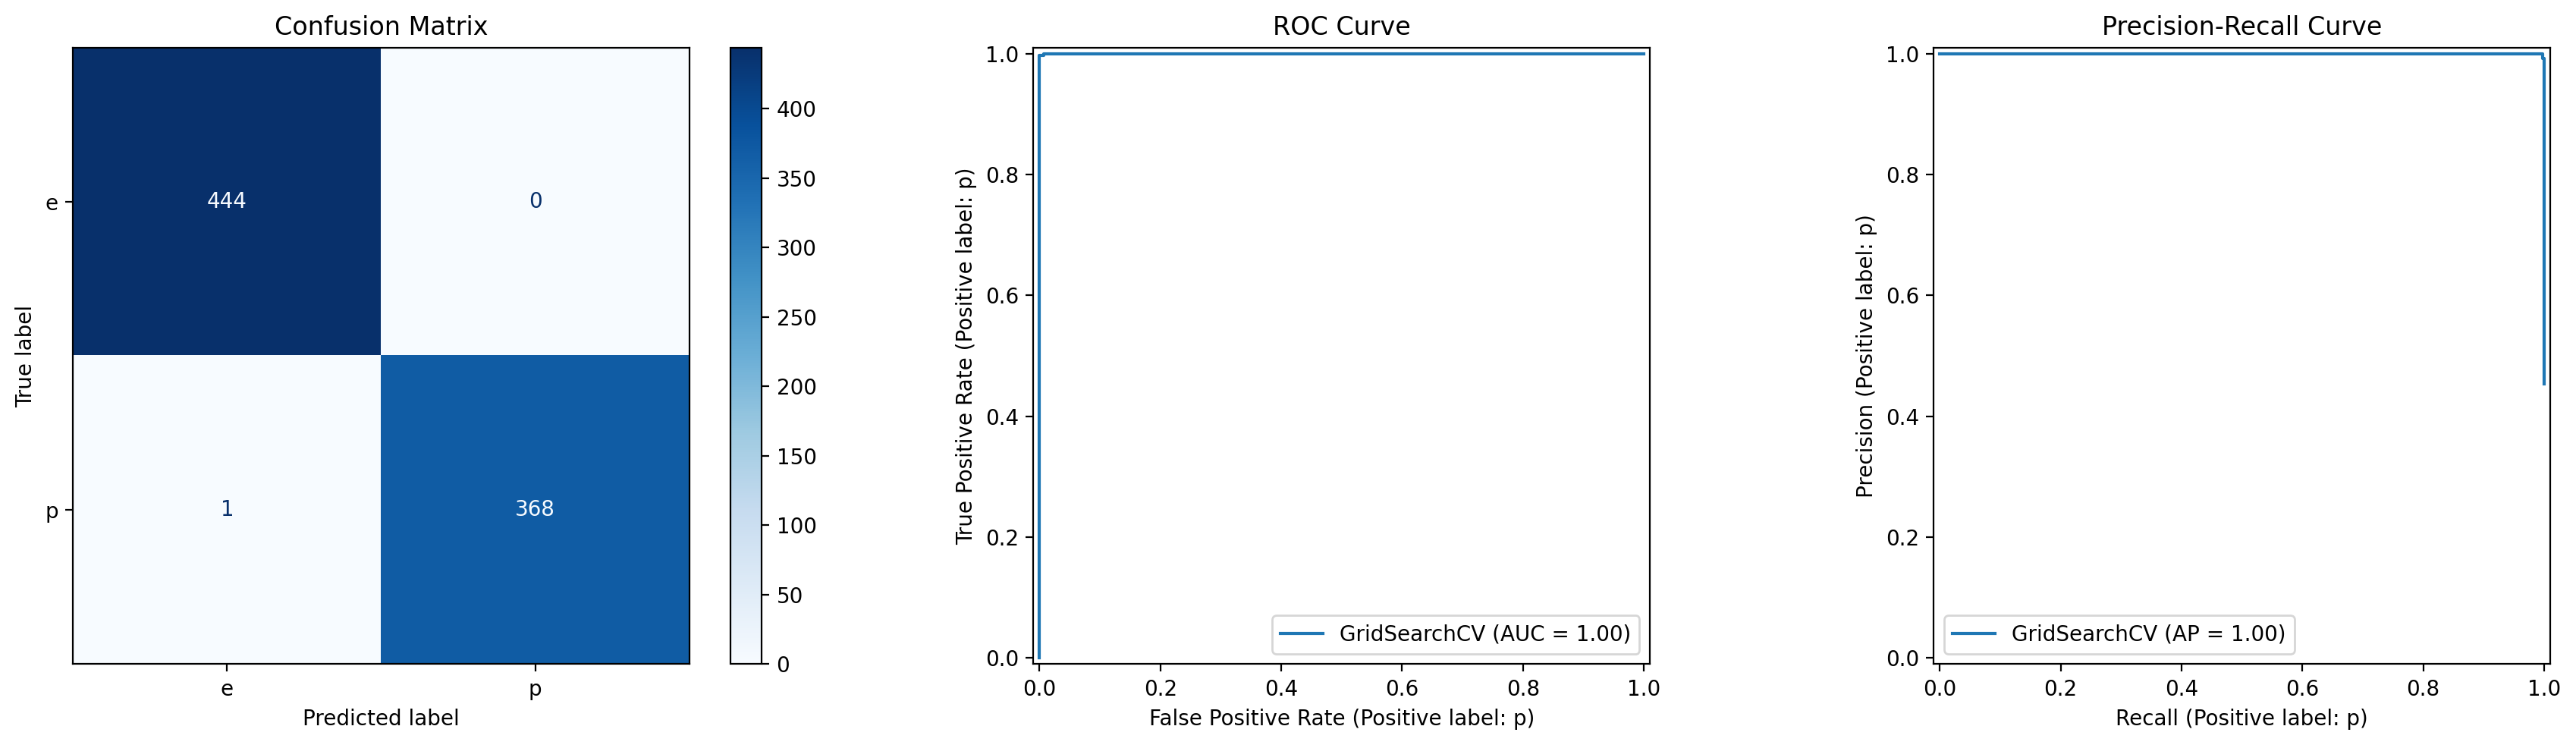

In [16]:
plot_metrics(grid_model, X_test, y_test)

In [17]:
y_pred = grid_model.predict(X_test)

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       444
           p       1.00      1.00      1.00       369

    accuracy                           1.00       813
   macro avg       1.00      1.00      1.00       813
weighted avg       1.00      1.00      1.00       813



In [19]:
grid_model.best_estimator_.feature_importances_[:20]

array([1.71990251e-04, 5.30593492e-16, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.68661908e-03, 5.27973782e-16, 9.22211142e-17,
       0.00000000e+00, 0.00000000e+00, 1.63070897e-16, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.46437478e-17,
       2.38983263e-03, 5.65243631e-02, 1.30525988e-04, 1.05815802e-02])

It’s also important to identify which features have the most influence on the prediction. In this case, the feature `odor_n` (which means the mushroom has no smell) has the greatest impact on the model. I’d like to remind you that this value indicates a mushroom without any noticeable smell ис usually edible. On the other hand, if a mushroom has a distinct odor, it is more likely to be poisonous. This feature alone contributes to more than 60% of the model’s decision-making, highlighting its significant importance.

In [20]:
features = pd.DataFrame(index = X.columns, data = grid_model.best_estimator_.feature_importances_, columns = ['Importance'])

In [21]:
features = features[features['Importance'] > 0]

In [22]:
features = features.reset_index()

In [23]:
features = features.sort_values('Importance')

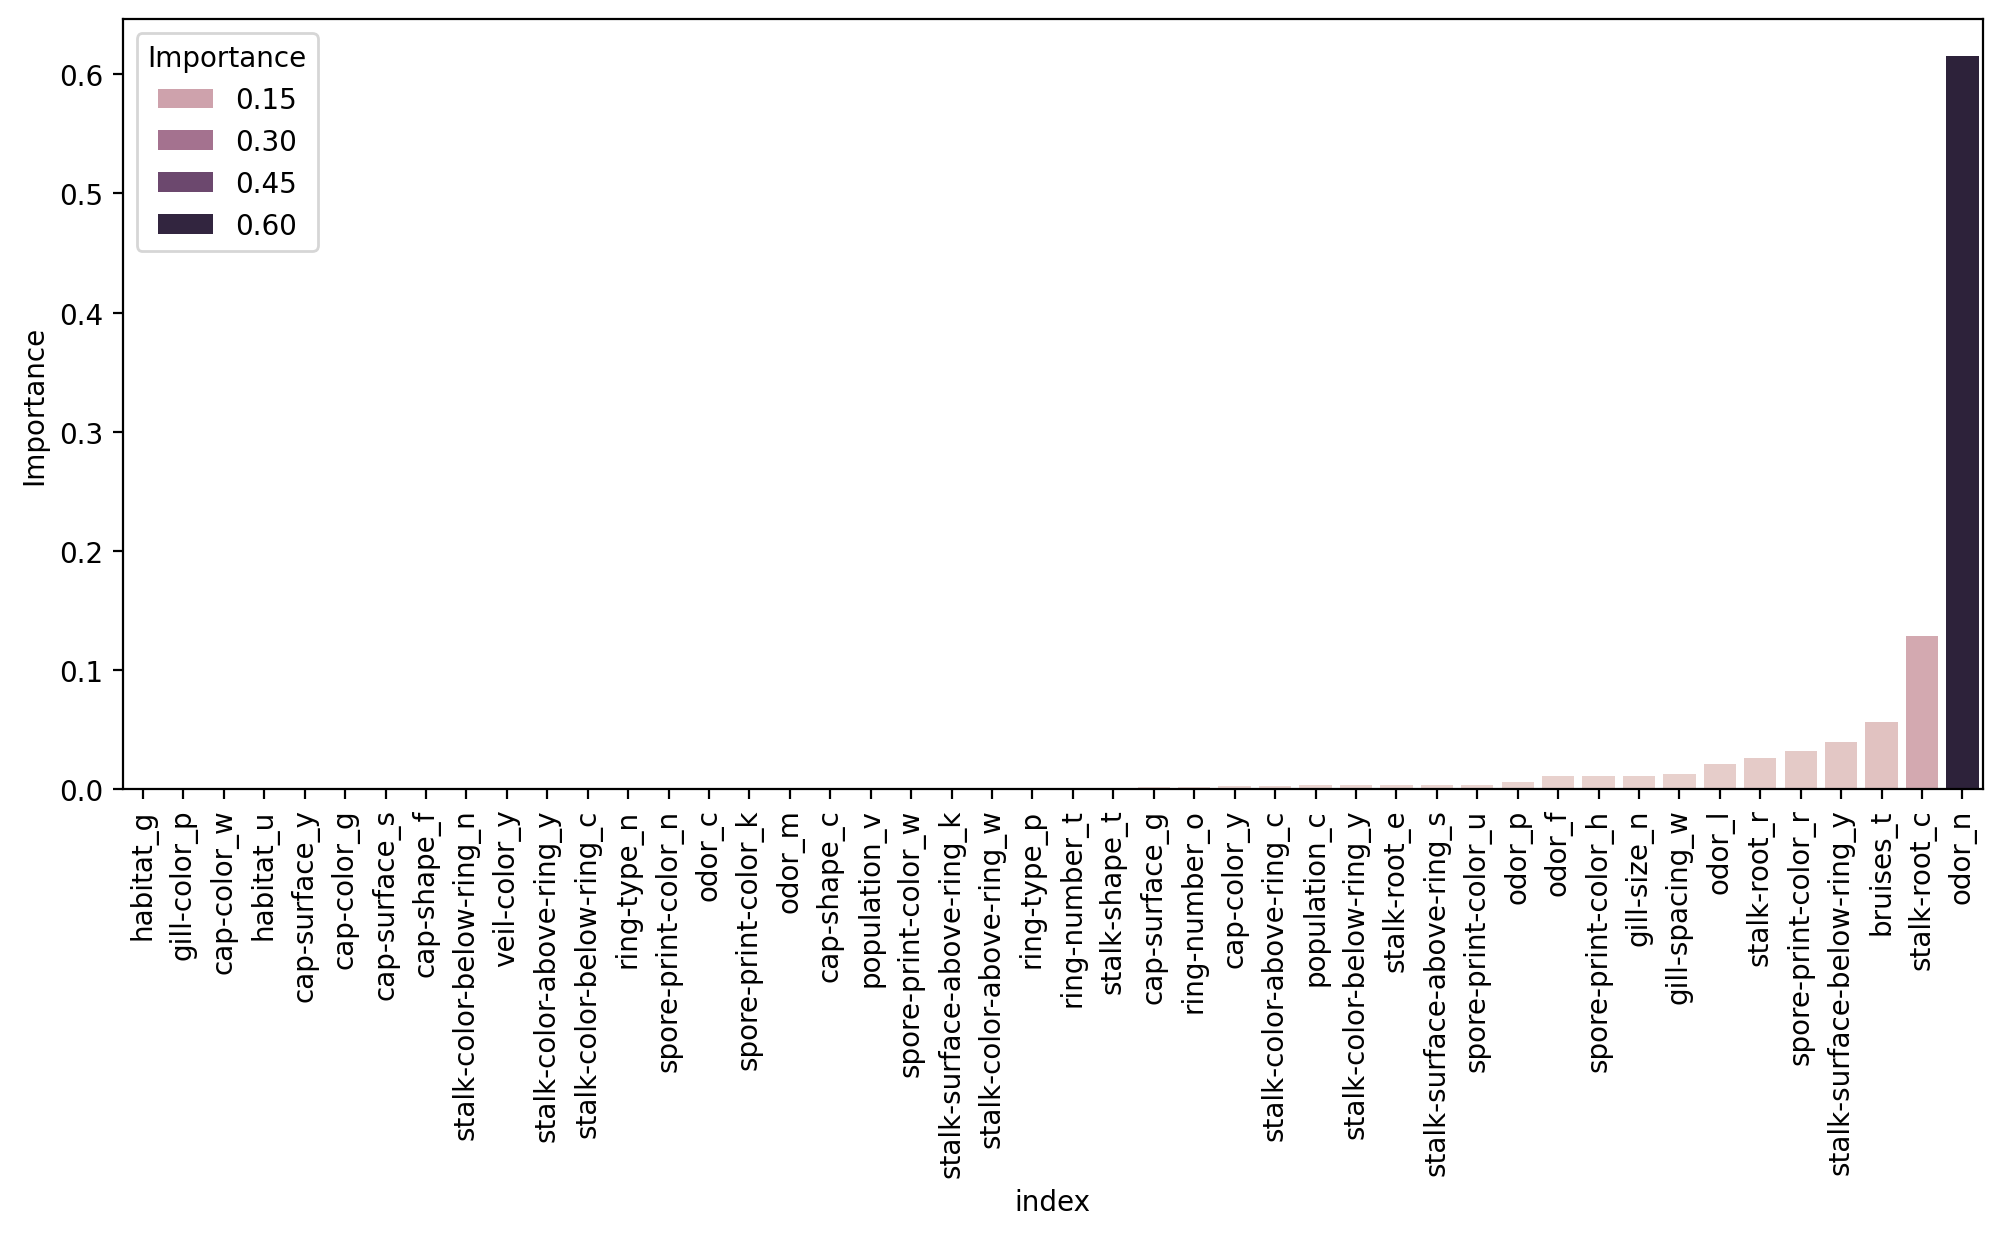

In [24]:
plt.figure(figsize = (12, 5))
sns.barplot(data = features, x = features['index'], y = 'Importance', hue = 'Importance')
plt.xticks(rotation = 90)
plt.show()

# 4. References
**[1]** https://en.wikipedia.org/wiki/Gradient_boosting

**[2]** https://www.kaggle.com/datasets/uciml/mushroom-classification/data